In [15]:
# Unemployment Analysis with Python

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [16]:
#  Load datasets
df1 = pd.read_csv("dataset/Unemployment_Rate_upto_11_2020.csv")
df2 = pd.read_csv("dataset/Unemployment in India.csv")

# Display first rows
df1.head(), df2.head()


(           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
 0  Andhra Pradesh   31-01-2020          M                              5.48   
 1  Andhra Pradesh   29-02-2020          M                              5.83   
 2  Andhra Pradesh   31-03-2020          M                              5.79   
 3  Andhra Pradesh   30-04-2020          M                             20.51   
 4  Andhra Pradesh   31-05-2020          M                             17.43   
 
     Estimated Employed   Estimated Labour Participation Rate (%) Region.1  \
 0             16635535                                     41.02    South   
 1             16545652                                     40.90    South   
 2             15881197                                     39.18    South   
 3             11336911                                     33.10    South   
 4             12988845                                     36.46    South   
 
    longitude  latitude  
 0    15.9129     79.7

In [17]:
#  Dataset information
df1.info()
df2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76

In [18]:
#  Rename columns for clarity 
df1.columns = [col.strip() for col in df1.columns]
df2.columns = [col.strip() for col in df2.columns]

df1.head()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [19]:
# Check missing values
df1.isnull().sum(), df2.isnull().sum()


(Region                                     0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
 Region.1                                   0
 longitude                                  0
 latitude                                   0
 dtype: int64,
 Region                                     28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
 Area                                       28
 dtype: int64)

In [22]:
# Step 1: Ensure Date column is string & strip spaces
df1['Date'] = df1['Date'].astype(str).str.strip()
df2['Date'] = df2['Date'].astype(str).str.strip()

# Step 2: Parse dates safely (day-first format)
df1['Date'] = pd.to_datetime(df1['Date'], dayfirst=True, errors='coerce')
df2['Date'] = pd.to_datetime(df2['Date'], dayfirst=True, errors='coerce')



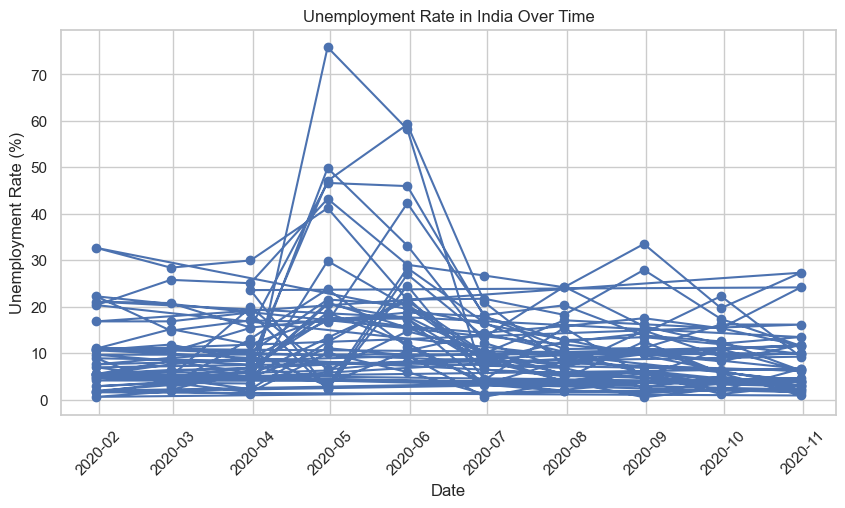

In [23]:
# National Unemployment Trend (Dataset 1)
plt.figure(figsize=(10,5))
plt.plot(df1['Date'], df1['Estimated Unemployment Rate (%)'], marker='o')
plt.title("Unemployment Rate in India Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()


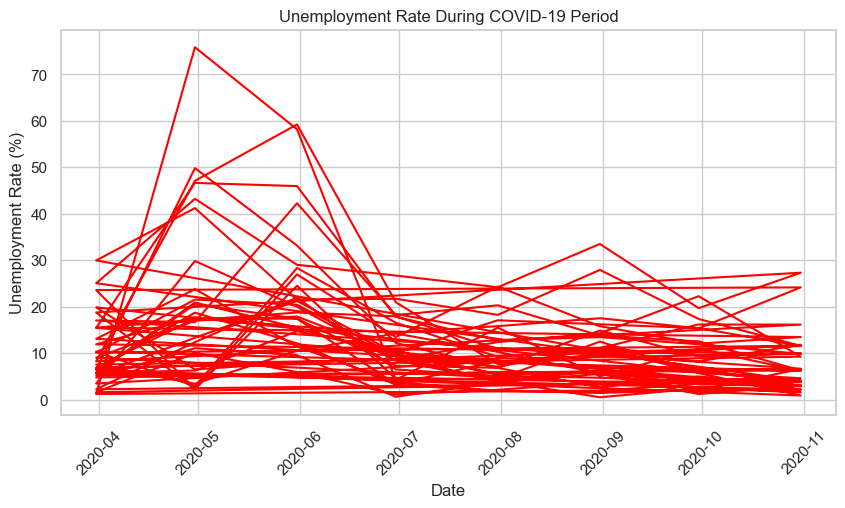

In [10]:
# 8. Covid-19 Impact Analysis
covid_period = df1[df1['Date'] >= '2020-03-01']

plt.figure(figsize=(10,5))
plt.plot(covid_period['Date'], covid_period['Estimated Unemployment Rate (%)'], color='red')
plt.title("Unemployment Rate During COVID-19 Period")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()


C:\Users\Shravani Gurav\AppData\Local\Temp\ipykernel_20408\150551602.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


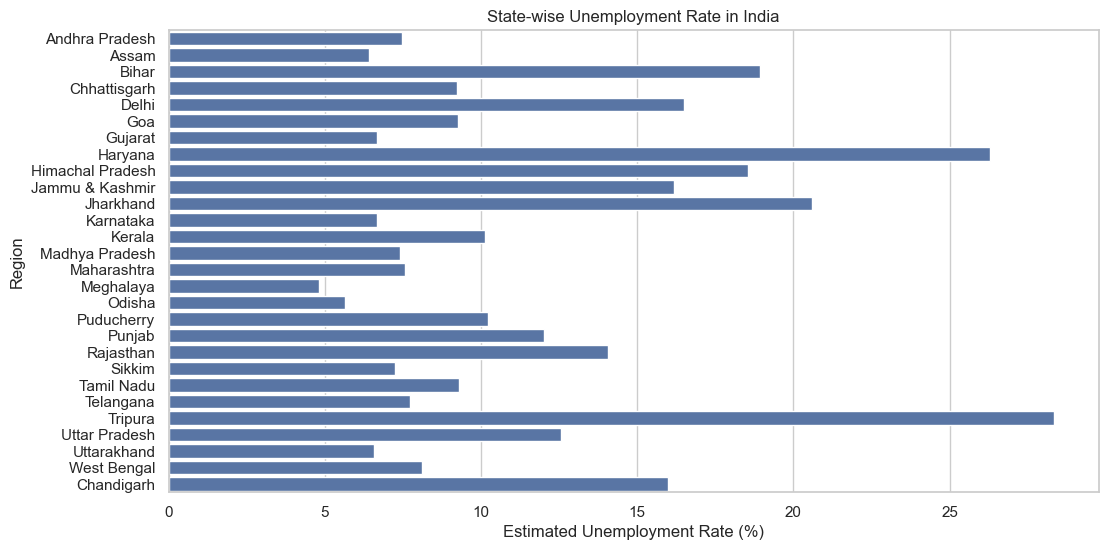

In [24]:
# State-wise Unemployment Analysis (Dataset 2)
plt.figure(figsize=(12,6))
sns.barplot(
    x='Estimated Unemployment Rate (%)',
    y='Region',
    data=df2,
    ci=None
)
plt.title("State-wise Unemployment Rate in India")
plt.show()


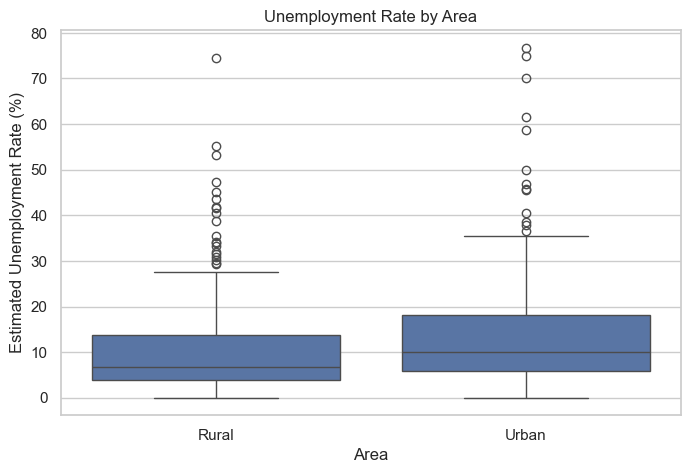

In [12]:
# 10. Area-wise Unemployment (Urban vs Rural)
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Area',
    y='Estimated Unemployment Rate (%)',
    data=df2
)
plt.title("Unemployment Rate by Area")
plt.show()


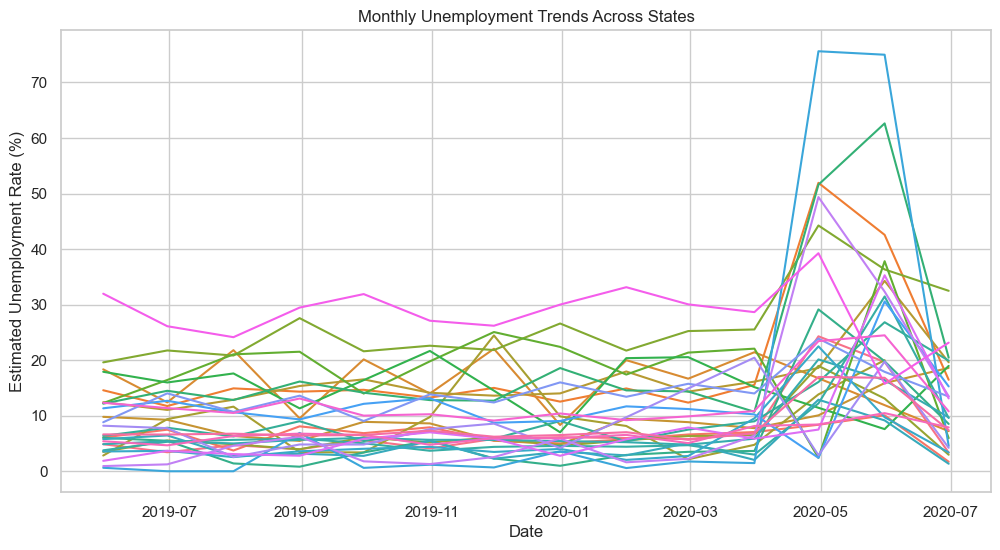

In [25]:
#  Monthly unemployment trend by state
state_trend = df2.groupby(['Region', 'Date'])['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(
    data=state_trend,
    x='Date',
    y='Estimated Unemployment Rate (%)',
    hue='Region',
    legend=False
)
plt.title("Monthly Unemployment Trends Across States")
plt.show()


In [26]:

print("Highest unemployment rate:",
      df2['Estimated Unemployment Rate (%)'].max())

print("Lowest unemployment rate:",
      df2['Estimated Unemployment Rate (%)'].min())


Highest unemployment rate: 76.74
Lowest unemployment rate: 0.0
